## Model Generalization on Unseen Datasets

Evaluate how the CNN Model performs on  unseen datasets (e.g., images collected from different clinics or MRI machines) in various metrics.

We will test using our trained weights on the testing folders of:
* `other1_brain_mri_dataset`
* `other2_brain_mri_dataset`


### Prep and Loading
This section handles image processing and loading the two datasets. The processing includes:  
* Resizing all brain MRI scans to a $256 \times 256$ resolution and converting them into PyTorch tensors.
* Transforming images to one channel through Grayscaling
* Organizing images into `Training` and `Testing` sets using `ImageFolder` (mapping subdirectories to class labels).
* Creates data streams (`DataLoaders`) to process images in batches of 32.

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount('/content/drive')


# paths to the Testing subfolders of new datasets
!cp -r "/content/drive/MyDrive/other1_brain_mri_dataset" "/content/"
!cp -r "/content/drive/MyDrive/other2_brain_mri_dataset" "/content/"

other1_path = '/content/other1_brain_mri_dataset/Testing/'
other2_path = '/content/other2_brain_mri_dataset/Testing/'

# transform for testing images by converting to Tensors with 256x256 ratio
transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),

])

# load datasets
other1_dataset = datasets.ImageFolder(root=other1_path, transform=transform_test)
other2_dataset = datasets.ImageFolder(root=other2_path, transform=transform_test)

# create dataloaders
other1_loader = torch.utils.data.DataLoader(other1_dataset, batch_size=64, shuffle=False, num_workers=2)
other2_loader = torch.utils.data.DataLoader(other2_dataset, batch_size=64, shuffle=False, num_workers=2)

class_names = other1_dataset.classes

print('Data Loaded Successfully...\n')

Mounted at /content/drive
Data Loaded Successfully...



### Model Architecture



In [2]:
import torch.nn as nn
import torch.optim as optim

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 256 -> 128
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # 128 -> 64
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(4, 4) # 64 -> 16
        )

        self.avgpool = nn.AdaptiveAvgPool2d((8, 8))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, num_classes),

        )


    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

### Model and Device Loading
This section loads the evaluation device and saved model weights for evaluation of datasets.

In [4]:
model = SimpleCNN(num_classes=len(class_names))
model = model.cuda() # I'm running on Google Colab GPU; pls change to your device when running on local machine

model.load_state_dict(torch.load('yi_cnn_ver2_result.pth'))
model.eval()
print('Model successfully built and weights loaded...\n')

Model successfully built and weights loaded...



### Define Evaluation Function
This section defines the function that runs the evaluation loop on datasets. For each dataset, it does the following:
* Prints classification report
* Generates and plots the Heat Map of Confusion Matrix

In [5]:
def test(model, loader):
    """Runs evaluation."""

    # running_loss = 0.0
    num_correct = 0
    num_samples = 0
    all_preds, all_labels = [], []


    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x = x.cuda()
            y = y.cuda()

            output = model(x)
            #loss = criterion(output, y)

            #running_loss += loss.item() * x.size(0)
            predicted = torch.max(output, 1)[1]
            num_correct += (predicted == y).sum().item()
            num_samples += y.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())


    #avg_loss = running_loss / num_samples
    accuracy = num_correct / num_samples
    f1 = f1_score(all_labels, all_preds, average='macro')
    return accuracy, f1, all_preds, all_labels

================ RESULT FOR other1_brain_mri_dataset ================
Eval: acc=0.9190, f1=0.9003
              precision    recall  f1-score   support

      glioma       0.96      0.92      0.94       254
  meningioma       0.85      0.94      0.90       306
    no_tumor       0.91      0.69      0.79       140
   pituitary       0.97      1.00      0.98       300

    accuracy                           0.92      1000
   macro avg       0.92      0.89      0.90      1000
weighted avg       0.92      0.92      0.92      1000



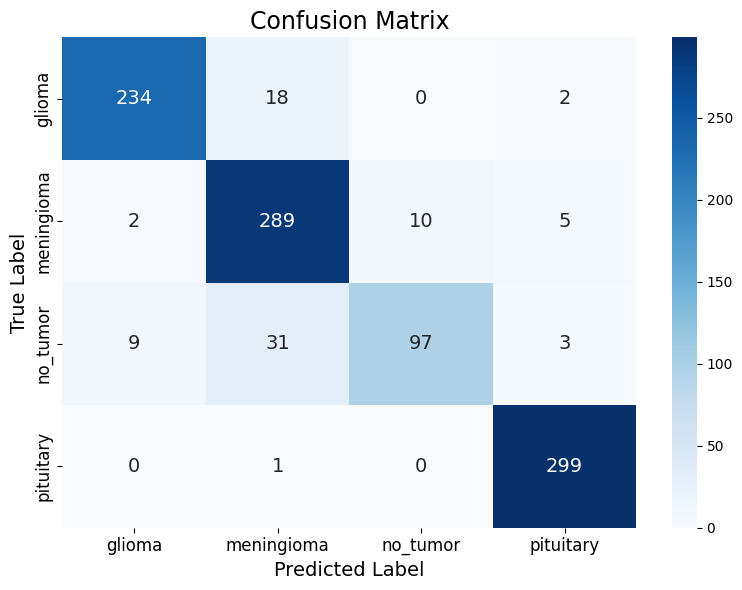

In [6]:
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

other_acc_1, other_f1_1, other_preds_1, other_labels_1 = test(model, other1_loader)

print("================ RESULT FOR other1_brain_mri_dataset ================")
print('Eval: acc=%.4f, f1=%.4f' % (other_acc_1, other_f1_1))
print(classification_report(other_labels_1, other_preds_1, target_names=class_names))



cm = confusion_matrix(other_labels_1, other_preds_1)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 14}
)

plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=17)

plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(rotation=90, fontsize=12)

plt.tight_layout()
plt.show()

================ RESULT FOR other2_brain_mri_dataset ================
Eval: acc=0.9609, f1=0.9630
              precision    recall  f1-score   support

      glioma       0.98      0.88      0.93       136
  meningioma       0.89      0.99      0.94       140
    no_tumor       1.00      0.98      0.99       100
   pituitary       1.00      0.99      1.00       136

    accuracy                           0.96       512
   macro avg       0.97      0.96      0.96       512
weighted avg       0.96      0.96      0.96       512



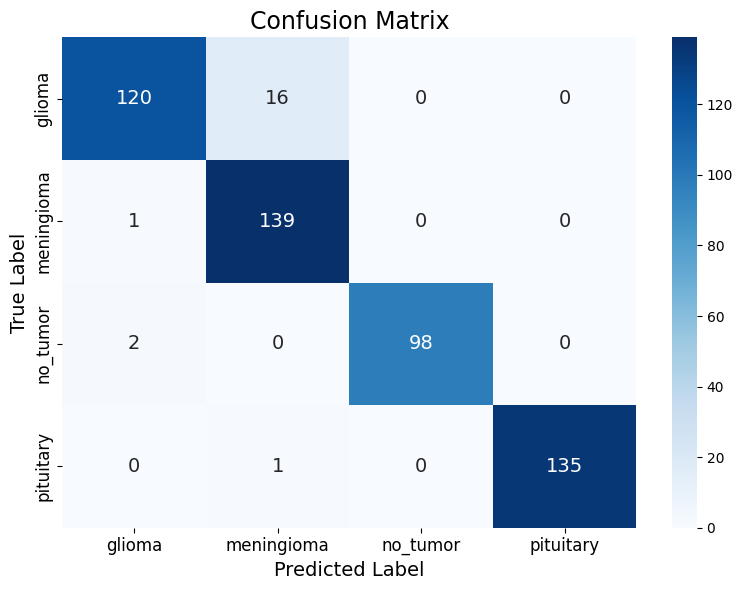

In [7]:
other_acc_2, other_f1_2, other_preds_2, other_labels_2 = test(model, other2_loader)

print("================ RESULT FOR other2_brain_mri_dataset ================")
print('Eval: acc=%.4f, f1=%.4f' % (other_acc_2, other_f1_2))
print(classification_report(other_labels_2, other_preds_2, target_names=class_names))


cm = confusion_matrix(other_labels_2, other_preds_2)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 14}
)

plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=17)

plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(rotation=90, fontsize=12)

plt.tight_layout()
plt.show()